In [14]:
from utils.camera import CameraDisplay
import time
import cv2

cam = CameraDisplay(lambda x: x)
cam.release()


Initializing camera...
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3264 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3264 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 120.000005 fps Duration = 8333333 ; Analog Gain range min 1.000000,

[ WARN:0@704.246] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

Camera released


In [15]:
import threading
import numpy as np

frame_count = 0
warmup_frames = 10
start_time = None
frame_threshold = 1000 + warmup_frames
frame_done = threading.Event()

input_image = np.empty((1, 3, 320, 320), dtype=np.float32)

prev_time = time.time()
frame_count = 0
start_time = None

session = None
input_tensor = None
output_tensor = None
io_binding = None

torch_net = None

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def onnx_callback(image):
    global prev_time, frame_count, start_time, input_image

    if frame_count == warmup_frames:
        start_time = time.time()

    if frame_count >= frame_threshold:
        frame_done.set()

    frame_count += 1

    fps = f"{int(1 / (time.time() - prev_time))}"
    prev_time = time.time()

    image = image[:320, :320, :]

    input_image[0] = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).transpose(2, 0, 1)
    input_image *= 1 / 255.0

    input_tensor.copy_(torch.from_numpy(input_image))

    session.run_with_iobinding(io_binding)
    output = output_tensor

    output = filter_boxes(output, threshold=0.25)
    output = nms(output, threshold=0.3)

    image_size = 320
    detections = output[0].cpu().numpy()

    for det in detections:
        xc, yc, bw, bh, score, cls = det

        x1 = int((xc - bw / 2) * image_size)
        y1 = int((yc - bh / 2) * image_size)
        x2 = int((xc + bw / 2) * image_size)
        y2 = int((yc + bh / 2) * image_size)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)

        cv2.putText(
            image,
            f"{score:.2f}",
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2,
        )

    cv2.putText(
        image,
        f"fps={fps}",
        (2, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (100, 255, 0),
        2,
        cv2.LINE_AA,
    )

    return image

def torch_callback(image):
    global prev_time, frame_count, start_time
    
    if frame_count == warmup_frames:
        start_time = time.time()

    if frame_count >= frame_threshold:
        frame_done.set()

    frame_count += 1
    fps = f"{int(1/(time.time() - prev_time))}"
    prev_time = time.time()

    image = image[:320, :320, :]

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    x = tf.functional.to_tensor(rgb)
    x = x.unsqueeze(0).to(device)

    #prepro_time = time.time()

    with torch.no_grad():
        output = torch_net(x)

    #infer_time = time.time()

    output = filter_boxes(output, threshold=0.25)
    output = nms(output, threshold=0.3)

    #post_time = time.time()

    image_size = 320
    detections = output[0].cpu().numpy()
    for det in detections:

        xc, yc, bw, bh, score, cls = det

        x1 = int((xc - bw/2) * image_size)
        y1 = int((yc - bh/2) * image_size)

        x2 = int((xc + bw/2) * image_size)
        y2 = int((yc + bh/2) * image_size)

        cv2.rectangle(image,
                        (x1,y1),
                        (x2,y2),
                        (0,0,255),
                        2)

        cv2.putText(image,
                    f"{score:.2f}",
                    (x1, max(20,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0,0,255),
                    2)

    cv2.putText(image, "fps="+fps, (2, 25), cv2.FONT_HERSHEY_SIMPLEX, 1,
                (100, 255, 0), 2, cv2.LINE_AA)
    
    #box_time = time.time()
    #print(prepro_time - self.prev_time)
    #print(infer_time - self.prev_time)
    #print(post_time - self.prev_time)
    #print(box_time - self.prev_time)
    return image


class BaseDetectionPipeline():

    def __init__(self, device):
        self.device = device

    def setup_model():
        pass

    def run_pipeline(self, model_type, name):
        """
        Runs only the model pipeline. Enter 'q' to stop it.
        """

        callback = onnx_callback if model_type == "onnx" else torch_callback
        cam = CameraDisplay(callback)

        cam.start()

        try:
            input(f"Press Enter to stop. {name}")
        finally:
            cam.stop()
            cam.release()

    def fps_pipeline(self, model_type):
        """
        Runs the model pipeline and measures the FPS.
        Stops after reaching frame_threshold.
        """
        global frame_count, start_time
    
        frame_count = 0
        frame_done.clear()
        start_time = time.time()

        callback = onnx_callback if model_type == "onnx" else torch_callback
    
        cam = CameraDisplay(callback)
        cam.start()
        
        frame_done.wait()
    
        cam.stop()
        cam.release()
    
        elapsed = time.time() - start_time
        measured_frames = frame_count - warmup_frames
        avg_fps = measured_frames / elapsed
        print(avg_fps)
    
        return avg_fps


In [16]:
import onnxruntime as ort

from utils.yolo import nms, filter_boxes

class OnnxDetectionPipeline(BaseDetectionPipeline):

    def __init__(self, device):
        super().__init__(device)
        self.input_image = np.empty((1,3,320,320), dtype=np.float32)
        self.prev_time = time.time()
        self.session = None
        self.input_tensor = None
        self.output_tensor = None
        self.io_binding = None

    def setup_model(self, onnx_path, output_tensor_value):
        self.session = ort.InferenceSession(
            onnx_path,
            providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
        )
        print("Setup IO_Binding")
        input_name = self.session.get_inputs()[0].name
        output_name = self.session.get_outputs()[0].name

        self.input_tensor = torch.empty(
            (1, 3, 320, 320),
            device=self.device,
            dtype=torch.float32
        )

        self.output_tensor = torch.empty(
            (1, 5, 10, 10, output_tensor_value),
            device=self.device,
            dtype=torch.float32
        )

        self.io_binding = self.session.io_binding()

        self.io_binding.bind_input(
            name=input_name,
            device_type=self.device,
            device_id=0,
            element_type=np.float32,
            shape=tuple(self.input_tensor.shape),
            buffer_ptr=self.input_tensor.data_ptr(),
        )

        self.io_binding.bind_output(
            name=output_name,
            device_type=self.device,
            device_id=0,
            element_type=np.float32,
            shape=tuple(self.output_tensor.shape),
            buffer_ptr=self.output_tensor.data_ptr(),
        )
        self.prev_time = time.time()

In [17]:

from torchvision import transforms as tf
from tinyyolov2 import TinyYoloV2

from utils.yolo import nms, filter_boxes

class TorchDetectionPipeline(BaseDetectionPipeline):

    def __init__(self, device):
        super().__init__(device)
        self.net = None
        self.prev_time = time.time()

    def setup_model(self, num_classes, state_dict_path):
        self.net = TinyYoloV2(num_classes=num_classes)
        self.net.load_state_dict(torch.load(state_dict_path, map_location=self.device))
        self.prev_time = time.time()


Setup Model Torch baseline
Initializing camera...


[ WARN:0@63.829] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


GST_ARGUS: Cleaning up
CONSUMER: Done Success
GST_ARGUS: Done Success
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3264 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3264 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 120.000005 fps Durat

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

/usr/local/lib/python3.8/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3191.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


...

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

Camera released
29.871120516448652
Setup Model ONNX pruned 80
GST_ARGUS: Cleaning up
CONSUMER: Done Success
GST_ARGUS: Done Success
Setup IO_Binding
Initializing camera...
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3264 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3264 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, ma

[ WARN:0@633.411] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

Camera released
29.870720763174493
Camera released
Camera released
Camera released
Camera released
Camera released
Camera released
Camera released
Camera released
Camera released


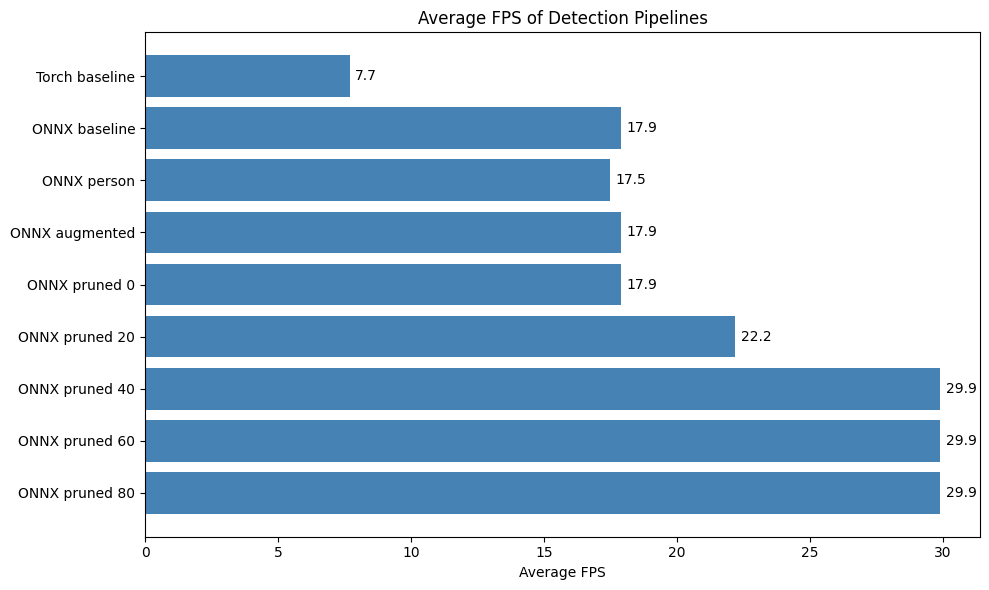

In [5]:
"""
FPS PIPELINE
Run to measure and plot fps of the following models.
"""


torch_models = [
    ("Torch baseline", "state_dicts/voc_pretrained.pt", 20),
]
"""
List of all torch models to test. 
Format: (name, path, num_classes)
"""

person_only_output_value = 6
base_output_value = 25
onnx_models = [
    ("ONNX baseline", "models/baseline_best_model.onnx", base_output_value),
    ("ONNX person", "models/person_best_model.onnx", person_only_output_value),
    ("ONNX augmented", "models/augmented_best_model.onnx", base_output_value),
    ("ONNX pruned 0", "models/pruned_pipeline_0_best_model.onnx", base_output_value),
    ("ONNX pruned 20", "models/pruned_pipeline_20_best_model.onnx", base_output_value),
    ("ONNX pruned 40", "models/pruned_pipeline_40_best_model.onnx", base_output_value),
    ("ONNX pruned 60", "models/pruned_pipeline_60_best_model.onnx", base_output_value),
    ("ONNX pruned 80", "models/pruned_pipeline_80_best_model.onnx", base_output_value),
]
"""
List of all onnx models to test. 
Format: (name, path, output_value)
"""

results = {}

# Torch models
torch_pipeline = TorchDetectionPipeline(device)
for name, path, num_classes in torch_models:
    print(f"Setup Model {name}")
    torch_pipeline.setup_model(num_classes, path)
    torch_net = torch_pipeline.net.to(device)
    
    results[name] = torch_pipeline.fps_pipeline("torch")
    frame_count = 0
    if device.type == "cuda":
        torch.cuda.empty_cache()

# ONNX models
onnx_pipeline = OnnxDetectionPipeline(device)
for name, path, output_tensor_value in onnx_models:
    print(f"Setup Model {name}")
    onnx_pipeline.setup_model(path, output_tensor_value)
    session = onnx_pipeline.session
    input_tensor = onnx_pipeline.input_tensor
    output_tensor = onnx_pipeline.output_tensor
    io_binding = onnx_pipeline.io_binding

    results[name] = onnx_pipeline.fps_pipeline("onnx")
    frame_count = 0
    if device.type == "cuda":
        torch.cuda.empty_cache()

import matplotlib.pyplot as plt

names = list(results.keys())
fps = np.round(list(results.values()), 1)

plt.figure(figsize=(10, 6))
bars = plt.barh(names, fps, color="steelblue")

plt.title("Average FPS of Detection Pipelines")
plt.xlabel("Average FPS")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center"
    )

# Highest FPS at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("results/fps_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [18]:
"""
Run PIPELINE
Run to let the models run as you like. Quit a model by pressing "q".
"""


torch_models = [
    ("Torch baseline", "state_dicts/voc_pretrained.pt", 20),
]
"""
List of all torch models to test. 
Format: (name, path, num_classes)
"""

person_only_output_value = 6
base_output_value = 25
onnx_models = [
    ("ONNX baseline", "models/baseline_best_model.onnx", base_output_value),
    ("ONNX person", "models/person_best_model.onnx", person_only_output_value),
    ("ONNX augmented", "models/augmented_best_model.onnx", base_output_value),
    ("ONNX pruned 0", "models/pruned_pipeline_0_best_model.onnx", base_output_value),
    ("ONNX pruned 20", "models/pruned_pipeline_20_best_model.onnx", base_output_value),
    ("ONNX pruned 40", "models/pruned_pipeline_40_best_model.onnx", base_output_value),
    ("ONNX pruned 60", "models/pruned_pipeline_60_best_model.onnx", base_output_value),
    ("ONNX pruned 80", "models/pruned_pipeline_80_best_model.onnx", base_output_value),
]
"""
List of all onnx models to test. 
Format: (name, path, output_value)
"""

# Torch models
torch_pipeline = TorchDetectionPipeline(device)
for name, path, num_classes in torch_models:
    print(f"Setup Model {name}")
    torch_pipeline.setup_model(num_classes, path)
    torch_net = torch_pipeline.net.to(device)
    
    torch_pipeline.run_pipeline("torch", name)
    frame_count = 0
    if device.type == "cuda":
        torch.cuda.empty_cache()

# ONNX models
onnx_pipeline = OnnxDetectionPipeline(device)
for name, path, output_tensor_value in onnx_models:
    print(f"Setup Model {name}")
    onnx_pipeline.setup_model(path, output_tensor_value)
    session = onnx_pipeline.session
    input_tensor = onnx_pipeline.input_tensor
    output_tensor = onnx_pipeline.output_tensor
    io_binding = onnx_pipeline.io_binding

    onnx_pipeline.run_pipeline("onnx", name)
    frame_count = 0
    if device.type == "cuda":
        torch.cuda.empty_cache()


Setup Model Torch baseline
GST_ARGUS: Cleaning up
CONSUMER: Done Success
GST_ARGUS: Done Success
Initializing camera...
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3264 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3264 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000

[ WARN:0@714.281] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

Press Enter to stop. Torch baseline 


Camera released
GST_ARGUS: Cleaning up
CONSUMER: Done Success
GST_ARGUS: Done Success
Setup Model ONNX baseline
Setup IO_Binding
Initializing camera...
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3264 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3264 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposur

...

Press Enter to stop. ONNX person 


Camera released
Setup Model ONNX augmented
Setup IO_BindingCONSUMER: Done Success
GST_ARGUS: Cleaning up
GST_ARGUS: Done Success

Initializing camera...


(Argus) Error EndOfFile: Unexpected error in reading socket (in src/rpc/socket/client/ClientSocketManager.cpp, function recvThreadCore(), line 266)
(Argus) Error EndOfFile: Receive worker failure, notifying 1 waiting threads (in src/rpc/socket/client/ClientSocketManager.cpp, function recvThreadCore(), line 340)
(Argus) Error InvalidState: Argus client is exiting with 1 outstanding client threads (in src/rpc/socket/client/ClientSocketManager.cpp, function recvThreadCore(), line 357)
(Argus) Error EndOfFile: Receiving thread terminated with error (in src/rpc/socket/client/ClientSocketManager.cpp, function recvThreadWrapper(), line 368)
(Argus) Error EndOfFile: Client thread received an error from socket (in src/rpc/socket/client/ClientSocketManager.cpp, function send(), line 145)
(Argus) Error EndOfFile:  (propagating from src/rpc/socket/client/SocketClientDispatch.cpp, function dispatch(), line 91)
Error generated. /dvs/git/dirty/git-master_linux/multimedia/nvgstreamer/gst-nvarguscamera

GST_ARGUS: Creating output stream
Camera released
Camera released
Camera released


RuntimeError: Could not initialize camera.  Please see error trace.